## Data Loading, Cleaning and Integration
### Railway Dataset (Kaggle)

containing station codes, train routes, and schedules. This will be cleaned up to count frequencies and calculate density spread.

https://www.kaggle.com/datasets/sripaadsrinivasan/indian-railways-dataset/data

It has three files, we construct a single railways table wherein each observation represents a station, along with the railway network data.

In [30]:
import pandas as pd
import json

# Load files
with open('schedules.json') as f:
    schedules_json = json.load(f)

with open('stations.json') as f:
    stations_json = json.load(f)

with open('trains.json') as f:
    trains_json = json.load(f)
# Convert to DataFrames
schedules = pd.json_normalize(schedules_json)
stations = pd.json_normalize(stations_json)
trains = pd.json_normalize(trains_json)

#### Stations

In [31]:
#quicklook
stations_df = pd.json_normalize(stations.loc[0, 'features'])
stations_df.shape #(8990,9)
stations_df.head()

,type,geometry.type,geometry.coordinates,properties.state,properties.code,properties.name,properties.zone,properties.address,geometry
0,Feature,Point,"[75.4516454, 27.2520587]",Rajasthan,BDHL,Badhal,NWR,"Kishangarh Renwal, Rajasthan",NaN
1,Feature,NaN,NaN,NaN,XX-BECE,XX-BECE,NaN,NaN,NaN
2,Feature,NaN,NaN,NaN,XX-BSPY,XX-BSPY,NaN,NaN,NaN
3,Feature,NaN,NaN,NaN,YY-BPLC,YY-BPLC,NaN,NaN,NaN
4,Feature,Point,"[79.519746, 28.913427000000002]",Uttar Pradesh,KHH,KICHHA,NER,"Kichha, Uttar Pradesh",NaN


In [32]:
#extract the attributes of each station- code,name,state,longitude,latitude
stations_df['station_code'] = stations_df['properties.code']
stations_df['station_name'] = stations_df['properties.name']
stations_df['state'] = stations_df['properties.state']
stations_df =stations_df[ stations_df['geometry.coordinates'].apply(lambda x: isinstance(x, (list, tuple)))].copy()
stations_df['lon'] = stations_df['geometry.coordinates'].apply(lambda x: x[0])
stations_df['lat'] = stations_df['geometry.coordinates'].apply(lambda x: x[1])
#construct the table for stations with each row representing a station- code,name,state,longitude,latitude
stations_clean= stations_df[['station_name','station_code', 'state', 'lat', 'lon']]

In [33]:
#clean the sttaion_code column ,and drop duplicates
stations_clean['station_code'] = stations_clean['station_code'].str.upper().str.strip()
stations_clean = stations_clean.drop_duplicates(subset=['station_code'])
stations_clean.shape

(8697, 5)

In [34]:
stations_clean.head()

,station_name,station_code,state,lat,lon
0,Badhal,BDHL,Rajasthan,27.252059,75.451645
4,KICHHA,KHH,Uttar Pradesh,28.913427,79.519746
5,Sherekan,SRKN,Rajasthan,29.555198,74.434991
6,Bhukarka,BKKA,Rajasthan,29.238227,74.751031
7,Nohar,NHR,Rajasthan,29.192563,74.773628


#### Trains

In [35]:
#quicklook
trains_df = pd.json_normalize(trains.loc[0, 'features'])
trains_df.shape #(5208,24)
trains_df.head(5)
##the geometry co-ordinates include the co-ords for every stop .

,type,geometry.type,geometry.coordinates,properties.third_ac,properties.arrival,properties.from_station_code,properties.name,properties.zone,properties.chair_car,properties.first_class,...,properties.departure,properties.return_train,properties.to_station_code,properties.second_ac,properties.classes,properties.to_station_name,properties.duration_h,properties.type,properties.first_ac,properties.distance
0,Feature,LineString,"[[74.880117, 32.706975], [74.953339, 32.762368...",0,12:15:00,JAT,Jammu Tawi Udhampur Special,NR,0,0,...,10:40:00,04602,UHP,0,,UDHAMPUR,1.0,DEMU,0,53.0
1,Feature,LineString,"[[75.154881, 32.92664], [75.14542599999999, 32...",0,08:35:00,UHP,UDHAMPUR JAMMUTAWI DMU,NR,0,0,...,06:45:00,04601,JAT,0,,JAMMU TAWI,1.0,DEMU,0,53.0
2,Feature,LineString,"[[74.880117, 32.706975], [74.953339, 32.762368...",0,17:50:00,JAT,JAT UDAHMPUR DMU,NR,0,0,...,16:15:00,04604,UHP,0,,UDHAMPUR,1.0,DEMU,0,53.0
3,Feature,LineString,"[[75.154881, 32.92664], [75.14542599999999, 32...",0,19:50:00,UHP,UDHAMPUR JAMMUTAWI DMU,NR,0,0,...,18:20:00,04603,JAT,0,,JAMMU TAWI,1.0,DEMU,0,53.0
4,Feature,LineString,"[[72.840535, 19.061911], [72.840078, 19.069166...",1,12:30:00,BDTS,Mumbai BandraT-Bikaner SF Special,NWR,0,0,...,14:35:00,04727,BKN,1,,BIKANER JN,21.0,SF,0,1212.0


In [36]:
#extract the attributes of each train- number,type,source,destination,return train number,duration,distance
trains_df['train_number'] = trains_df['properties.number']
#trains_df['train_type'] = trains_df['properties.type']
trains_df['source'] = trains_df['properties.from_station_code']
trains_df['destination'] = trains_df['properties.to_station_code']
trains_df['return_train'] = trains_df['properties.return_train']
trains_df['duration'] = trains_df['properties.duration_h']
trains_df['distance'] = trains_df['properties.distance']
#construct the table for trains with each row representing a  train- number,type,source,destination,return train number,duration,distance,and co-ordinates of all the stops
trains_clean = trains_df[['train_number','geometry.coordinates','source','destination','return_train','duration','distance']]
trains_clean.shape

(5208, 7)

In [37]:
trains_clean.head(5)

,train_number,geometry.coordinates,source,destination,return_train,duration,distance
0,04601,"[[74.880117, 32.706975], [74.953339, 32.762368...",JAT,UHP,04602,1.0,53.0
1,04602,"[[75.154881, 32.92664], [75.14542599999999, 32...",UHP,JAT,04601,1.0,53.0
2,04603,"[[74.880117, 32.706975], [74.953339, 32.762368...",JAT,UHP,04604,1.0,53.0
3,04604,"[[75.154881, 32.92664], [75.14542599999999, 32...",UHP,JAT,04603,1.0,53.0
4,04728,"[[72.840535, 19.061911], [72.840078, 19.069166...",BDTS,BKN,04727,21.0,1212.0


##### Extract each stop, their co-ordinates, and match it with the station code such that each train has records for every station that it connects.


In [38]:
trains_exp = trains_clean.explode('geometry.coordinates')
trains_exp['lon'] = trains_exp['geometry.coordinates'].apply(lambda x: x[0])
trains_exp['lat'] = trains_exp['geometry.coordinates'].apply(lambda x: x[1])
trains_exp.head(25)


,train_number,geometry.coordinates,source,destination,return_train,duration,distance,lon,lat
0,04601,"[74.880117, 32.706975]",JAT,UHP,04602,1.0,53.0,74.880117,32.706975
0,04601,"[74.953339, 32.762368]",JAT,UHP,04602,1.0,53.0,74.953339,32.762368
0,04601,"[75.044078, 32.80617]",JAT,UHP,04602,1.0,53.0,75.044078,32.806170
0,04601,"[75.13222499999999, 32.769105]",JAT,UHP,04602,1.0,53.0,75.132225,32.769105
0,04601,"[75.14542599999999, 32.863528]",JAT,UHP,04602,1.0,53.0,75.145426,32.863528
0,04601,"[75.154881, 32.92664]",JAT,UHP,04602,1.0,53.0,75.154881,32.926640
1,04602,"[75.154881, 32.92664]",UHP,JAT,04601,1.0,53.0,75.154881,32.926640
1,04602,"[75.14542599999999, 32.863528]",UHP,JAT,04601,1.0,53.0,75.145426,32.863528
1,04602,"[75.13222499999999, 32.769105]",UHP,JAT,04601,1.0,53.0,75.132225,32.769105
1,04602,"[75.044078, 32.80617]",UHP,JAT,04601,1.0,53.0,75.044078,32.806170


In [39]:
trains_exp.shape

(414420, 9)

In [40]:
# map train stops to stations
from scipy.spatial import cKDTree
import numpy as np

station_coords = stations_clean[['lat', 'lon']].values
tree = cKDTree(station_coords)
train_coords = trains_exp[['lat', 'lon']].values
dist, idx = tree.query(train_coords, k=1)
#map it with stations dataset
trains_exp['station_code'] = stations_clean.iloc[idx]['station_code'].values
trains_exp.head(10)

,train_number,geometry.coordinates,source,destination,return_train,duration,distance,lon,lat,station_code
0,04601,"[74.880117, 32.706975]",JAT,UHP,04602,1.0,53.0,74.880117,32.706975,JAT
0,04601,"[74.953339, 32.762368]",JAT,UHP,04602,1.0,53.0,74.953339,32.762368,BLA
0,04601,"[75.044078, 32.80617]",JAT,UHP,04602,1.0,53.0,75.044078,32.806170,SGRR
0,04601,"[75.13222499999999, 32.769105]",JAT,UHP,04602,1.0,53.0,75.132225,32.769105,MNWL
0,04601,"[75.14542599999999, 32.863528]",JAT,UHP,04602,1.0,53.0,75.145426,32.863528,RMJK
0,04601,"[75.154881, 32.92664]",JAT,UHP,04602,1.0,53.0,75.154881,32.926640,UHP
1,04602,"[75.154881, 32.92664]",UHP,JAT,04601,1.0,53.0,75.154881,32.926640,UHP
1,04602,"[75.14542599999999, 32.863528]",UHP,JAT,04601,1.0,53.0,75.145426,32.863528,RMJK
1,04602,"[75.13222499999999, 32.769105]",UHP,JAT,04601,1.0,53.0,75.132225,32.769105,MNWL
1,04602,"[75.044078, 32.80617]",UHP,JAT,04601,1.0,53.0,75.044078,32.806170,SGRR


In [41]:
#Mark Terminals(as in the no.of times,the station has served as either the source or destination)
trains_exp['is_terminal'] = (
    trains_exp.groupby('train_number').cumcount().eq(0) |
    trains_exp.groupby('train_number').cumcount(ascending=False).eq(0)
)
#create a new table where each row is that of a station, including the trains info
trains_mapped = (
    trains_exp
    .groupby(['lat', 'lon'])
    .agg(
        unique_trains=('train_number', 'nunique'),
        terminal_count=('is_terminal', 'sum'),
        avg_distance=('distance', 'mean'),
        avg_duration=('duration', 'mean')
    ))

#Attach station_code (assuming it exists in trains_exp)
station_map = (
    trains_exp[['lat', 'lon', 'station_code']]
    .drop_duplicates()
)

trains_mapped =  trains_mapped.merge(
    station_map,
    on=['lat', 'lon'],
    how='left'
)
#reorder columns
cols = ['station_code', 'lat', 'lon'] + \
       [c for c in trains_mapped.columns if c not in ['station_code', 'lat', 'lon']]

trains_mapped = trains_mapped[cols]
trains_mapped.head(30)

,station_code,lat,lon,unique_trains,terminal_count,avg_distance,avg_duration
0,CAPE,8.088028,77.542504,22,22,1605.000000,30.227273
1,SUCH,8.149479,77.466792,22,0,1605.000000,30.227273
2,NCJ,8.173850,77.443470,65,38,1229.969231,23.430769
3,VRLR,8.194645,77.368699,36,0,1447.805556,28.000000
4,NJT,8.199572,77.419432,36,0,1447.805556,28.000000
5,ERL,8.212549,77.308161,36,0,1447.805556,28.000000
6,THX,8.228258,77.506216,34,0,1256.676471,23.235294
7,AAY,8.249451,77.529265,34,0,1256.676471,23.235294
8,PYD,8.265150,77.259683,36,0,1447.805556,28.000000
9,KZT,8.302348,77.218817,36,0,1447.805556,28.000000


In [42]:
trains_mapped.shape

(8240, 7)

#### schedules

In [43]:
schedules.head()

,arrival,day,train_name,station_name,station_code,id,train_number,departure
0,None,1.0,Falaknuma Lingampalli MMTS,KACHEGUDA FALAKNUMA,FM,302214,47154,07:55:00
1,None,1.0,Thrissur Guruvayur Passenger,THRISUR,TCR,281458,56044,18:55:00
2,None,1.0,Porbandar Muzaffarpur Express,PORBANDAR,PBR,309335,19269,15:05:00
3,None,1.0,RAIPUR ITWARI PASS,RAIPUR JN,R,283774,58205,13:30:00
4,None,1.0,Gomoh-Asansol MEMU,GOMOH JN,GMO,319937,63542,07:20:00


In [44]:
schedules.shape

(417080, 8)

In [45]:
#Calculate the frequency of trains for each station
station_stats = (
    schedules
    .groupby('station_code')
    .size()
    .reset_index(name='frequency')
)
station_stats.shape

(8539, 2)

In [46]:
#merge with the dataset from stations+trains to get the final Railways dataset.
trains_mapped = trains_mapped.merge(
    station_stats,
    on='station_code',
    how='left')

trains_mapped.head(10)

,station_code,lat,lon,unique_trains,terminal_count,avg_distance,avg_duration,frequency
0,CAPE,8.088028,77.542504,22,22,1605.000000,30.227273,22
1,SUCH,8.149479,77.466792,22,0,1605.000000,30.227273,22
2,NCJ,8.173850,77.443470,65,38,1229.969231,23.430769,65
3,VRLR,8.194645,77.368699,36,0,1447.805556,28.000000,36
4,NJT,8.199572,77.419432,36,0,1447.805556,28.000000,36
5,ERL,8.212549,77.308161,36,0,1447.805556,28.000000,36
6,THX,8.228258,77.506216,34,0,1256.676471,23.235294,34
7,AAY,8.249451,77.529265,34,0,1256.676471,23.235294,34
8,PYD,8.265150,77.259683,36,0,1447.805556,28.000000,36
9,KZT,8.302348,77.218817,36,0,1447.805556,28.000000,36


In [47]:
trains_mapped.describe()

,lat,lon,unique_trains,terminal_count,avg_distance,avg_duration,frequency
count,8240.000000,8240.000000,8240.000000,8240.000000,8239.000000,8239.000000,8240.000000
mean,22.385179,79.941123,50.163956,1.262985,1068.809902,20.771739,50.292718
std,5.457571,5.270193,51.123761,7.780746,648.606927,11.334430,51.214451
min,8.088028,68.967841,1.000000,0.000000,0.000000,0.000000,1.000000
25%,19.003312,76.045141,10.000000,0.000000,510.800000,11.619048,10.000000
50%,23.402674,78.897998,30.000000,0.000000,1100.166667,21.825000,31.000000
75%,26.343850,83.891994,75.000000,0.000000,1563.945076,29.254386,75.000000
max,32.982814,95.725374,298.000000,263.000000,3578.000000,66.500000,312.000000


In [48]:
#unique trains and frequency look similar,check
trains_mapped[
    trains_mapped['frequency'] > trains_mapped['unique_trains']
].sort_values(by='frequency', ascending=False).head(5)

,station_code,lat,lon,unique_trains,terminal_count,avg_distance,avg_duration,frequency
6288,CNB,26.454240,80.350966,298,46,1270.246795,23.166667,312
5224,MGS,25.278149,83.119250,258,29,1514.564202,27.031128,259
2700,UDN,21.171156,72.851461,229,0,1445.588745,26.203463,231
1731,MIPM,17.736300,83.252629,139,0,1823.538462,34.081448,225
5335,NYN,25.393138,81.860042,208,0,1581.621622,28.144144,222


In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod import families
from pathlib import Path

### Districts-Census 

https://www.kaggle.com/datasets/danofer/india-census?select=india-districts-census-2011.csv

containing district-level data from census 2011. 

In [50]:
census = pd.read_csv('india-districts-census-2011.csv')
census=census[['District code',
 'State name',
 'District name',
 'Population',
 'Female',             
 'Literate',
 'Male_Literate',
 'Female_Literate',
 'SC',
 'ST', 
 'Workers',
 'Main_Workers',
 'Marginal_Workers',
 'Non_Workers',
 'Cultivator_Workers',
 'Agricultural_Workers',
 'Household_Workers',
 'Other_Workers',
 'LPG_or_PNG_Households',
 'Housholds_with_Electric_Lighting',
 'Households_with_Internet',
 'Households_with_Computer',
 'Urban_Households',
 'Households',
 'Secondary_Education',
 'Graduate_Education',
 'Literate_Education',
 'Illiterate_Education',
 'Total_Education',
 'Age_Group_50', 
 'Households_with_Television']]
 

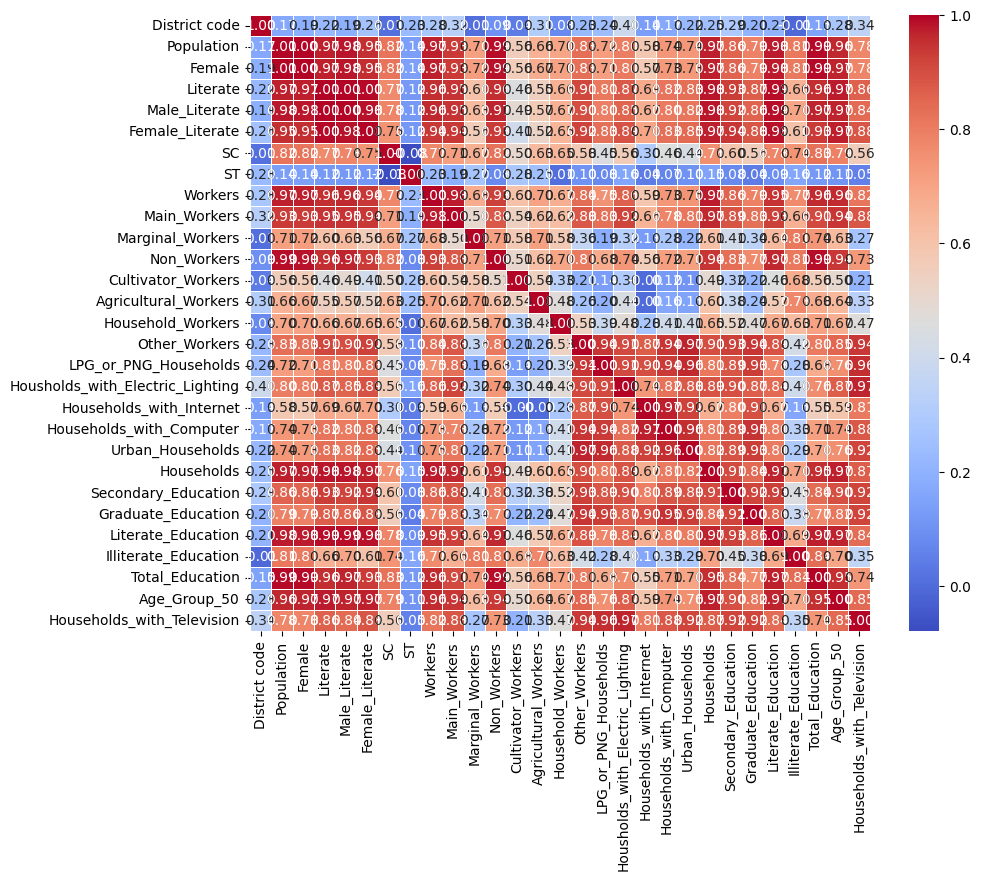

In [51]:

import seaborn as sns
numeric_df = census.select_dtypes(include='number')
#Correlation Plot for numerical data
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [52]:
#Lots of co-rrelation so we try to make them into blocks,and come up with interaction terms and indices.

##### Rail
    -Terminal
    -Efficiency Index
    -Stations
    -High_service Indicator
    
##### Demand
    -Worker 
    -Urban Rate
    -Agri Share
Share census['worker_share'] = census['Workers'] / census['Population']
census['agri_share'] = census['Agricultural_Workers'] / census['Workers']
census['urban_rate'] = census['Urban_Households'] / census['Households']    

##### Development 
    -hr_index(PCA on these terms was performed)
    
    (census['literacy_rate'] = census['Literate'] / census['Population']
    census['secondary_share'] = census['Secondary_Education'] / census['Population']
    census['graduate_share'] = census['Graduate_Education'] / census['Population'])
    
##### Need(Social Vulnerability Index)
    -SVI (PCA on these terms was performed)
    
    (census['elderly_share'] = census['Age_Group_50'] / census['Population']
    census['female_illiteracy'] = (census['Female'] - census['Female_Literate']) / census['Female'],
    census['sc_share'] = census['SC'] / census['Population']
    census['st_share'] = census['ST'] / census['Population'])



In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

In [54]:
#Demand
census['worker_share'] = census['Workers'] / census['Population']
census['agri_share'] = census['Agricultural_Workers'] / census['Workers']
census['urban_rate'] = census['Urban_Households'] / census['Households']
census['main_worker_share'] = census['Main_Workers'] / census['Workers']
census[['urban_rate', 'agri_share', 'worker_share', 'main_worker_share']].corr()
demand_features = [
    'worker_share',
    'agri_share',
    'urban_rate',
    'main_worker_share'
]
X = census[demand_features].replace([np.inf, -np.inf], np.nan).dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
census.loc[X.index, 'demand_index'] = pca.fit_transform(X_scaled)

In [55]:
loadings = pd.Series(pca.components_[0], index=demand_features)
print(loadings.sort_values(ascending=False))
census['demand_index'] = -census['demand_index']
census['demand_index_norm'] = (
    (census['demand_index'] - census['demand_index'].min()) /
    (census['demand_index'].max() - census['demand_index'].min())
)

urban_rate           0.627601
main_worker_share    0.575311
worker_share        -0.118810
agri_share          -0.510900
dtype: float64


In [56]:
#Consumption

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

census['internet_rate'] = census['Households_with_Internet'] / census['Households']
census['lpg_rate'] = census['LPG_or_PNG_Households'] / census['Households']
census['electricity_rate'] = census['Housholds_with_Electric_Lighting'] / census['Households']
census['computer_rate'] = census['Households_with_Computer'] / census['Households']
census['television_rate'] = census['Households_with_Television'] / census['Households']

wealth_features = [
    #'internet_rate',
    'lpg_rate',
    'electricity_rate',
    #'computer_rate',
    'television_rate'
]

X = census[wealth_features].replace([np.inf, -np.inf], np.nan).dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
census.loc[X.index, 'consumption_index'] = pca.fit_transform(X_scaled)


In [57]:
loadings = pd.Series(pca.components_[0], index=wealth_features)
print(loadings.sort_values(ascending=False))
census['consumption_index'] = -census['consumption_index']
census['consumption_index_norm'] = (
    (census['consumption_index'] - census['consumption_index'].min()) /
    (census['consumption_index'].max() - census['consumption_index'].min())
)
                      

television_rate     0.605102
lpg_rate            0.569060
electricity_rate    0.556797
dtype: float64


In [58]:
#Development
census['literacy_rate'] = census['Literate'] / census['Population']
census['secondary_share'] = census['Secondary_Education'] / census['Population']
census['graduate_share'] = census['Graduate_Education'] / census['Population']

hr_features = [
    'literacy_rate',
    'secondary_share',
    'graduate_share'
]
X = census[hr_features].replace([np.inf, -np.inf], np.nan).dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
census.loc[X.index, 'hr_index'] = pca.fit_transform(X_scaled)

In [59]:
#Needs
#calculate social vulnerability index (use rates consistently)
# Demographic vulnerability
census['elderly_share'] = census['Age_Group_50'] / census['Population']

# Educational vulnerability
census['female_illiteracy'] = (census['Female'] - census['Female_Literate']) / census['Female']

# Social disadvantage
census['sc_share'] = census['SC'] / census['Population']
census['st_share'] = census['ST'] / census['Population']
features = [
    'elderly_share',
    'female_illiteracy',
    'sc_share',
    'st_share'
]

X = census[features].replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
census.loc[X.index, 'SVI'] = pca.fit_transform(X_scaled)


In [60]:
loadings = pd.Series(pca.components_[0], index=features)
print(loadings.sort_values(ascending=False))
census['SVI'] = -census['SVI']
census['SVI_norm'] = (
    (census['SVI'] - census['SVI'].min()) /
    (census['SVI'].max() - census['SVI'].min())
)

elderly_share        0.567830
sc_share             0.487341
female_illiteracy   -0.370295
st_share            -0.550409
dtype: float64


In [61]:
census=census[['District code',
 'State name',
 'District name',
 'Population','worker_share',
    'agri_share',
    'urban_rate',
    'main_worker_share','lpg_rate',
    'electricity_rate',
    #'computer_rate',
    'television_rate','hr_index','SVI_norm']]

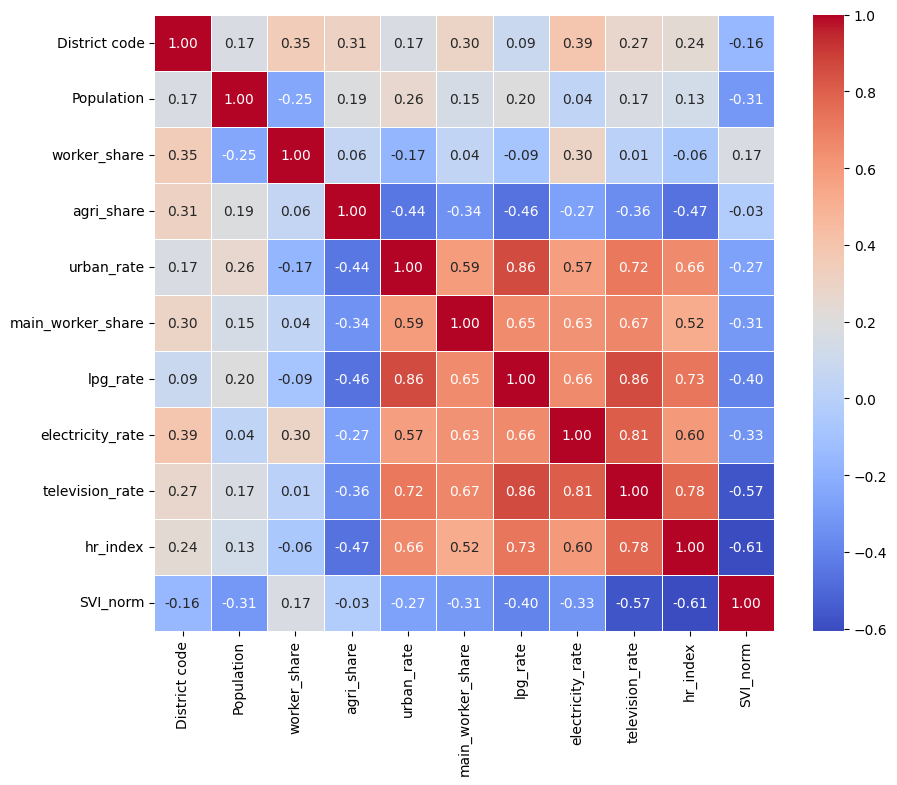

In [62]:
import seaborn as sns
numeric_df = census.select_dtypes(include='number')
#Correlation Plot for numerical data
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()



In [63]:
census=census[['District code',
 'State name',
 'District name',
 'Population','worker_share',
    'agri_share',
    'urban_rate','hr_index',
    'SVI_norm']]

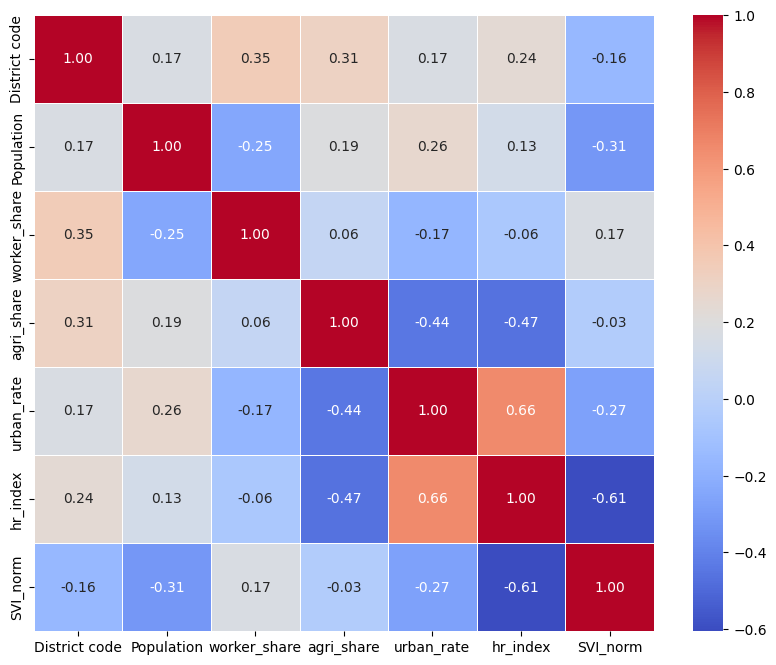

In [64]:
import seaborn as sns
numeric_df = census.select_dtypes(include='number')
#Correlation Plot for numerical data
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [65]:
census.head(5)

,District code,State name,District name,Population,worker_share,agri_share,urban_rate,hr_index,SVI_norm
0,1,JAMMU AND KASHMIR,Kupwara,870354,0.263185,0.247787,0.127851,-1.431037,0.703981
1,2,JAMMU AND KASHMIR,Badgam,753745,0.285065,0.170478,0.144752,-1.525485,0.674523
2,3,JAMMU AND KASHMIR,Leh(Ladakh),133487,0.562444,0.021910,0.321249,0.560910,0.684129
3,4,JAMMU AND KASHMIR,Kargil,140802,0.368411,0.072543,0.161474,-0.407111,0.824215
4,5,JAMMU AND KASHMIR,Punch,476835,0.338467,0.195690,0.103583,-0.962233,0.706597


### geocodes for Districts

In [66]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [67]:
import geopandas as gpd

districts = gpd.read_file('districts.json')
print(districts.head())
print(districts.geometry.head())

     DISTRICT           ST_NM  ST_CEN_CD  DT_CEN_CD  censuscode  \
0    Adilabad  Andhra Pradesh         28          1         532   
1        Agra   Uttar Pradesh          9         15         146   
2   Ahmadabad         Gujarat         24          7         474   
3  Ahmadnagar     Maharashtra         27         26         522   
4      Aizawl         Mizoram         15          3         283   

                                            geometry  
0  POLYGON ((78.84972 19.7601, 78.84368 19.76316,...  
1  POLYGON ((78.19803 27.4028, 78.19144 27.40206,...  
2  MULTIPOLYGON (((72.33607 23.10727, 72.32631 23...  
3  POLYGON ((74.67333 19.9467, 74.65898 19.94705,...  
4  POLYGON ((92.99965 24.40013, 92.9972 24.39843,...  
0    POLYGON ((78.84972 19.7601, 78.84368 19.76316,...
1    POLYGON ((78.19803 27.4028, 78.19144 27.40206,...
2    MULTIPOLYGON (((72.33607 23.10727, 72.32631 23...
3    POLYGON ((74.67333 19.9467, 74.65898 19.94705,...
4    POLYGON ((92.99965 24.40013, 92.9972 24.39

In [68]:
census.shape

(640, 9)

In [69]:
districts.shape

(641, 6)

In [70]:
codes = [235, 515, 417, 557, 406, 30, 93]

census[census['District code'].isin(codes)][['District code', 'District name']]

,District code,District name
29,30,Bilaspur
92,93,East
234,235,Aurangabad
405,406,Bilaspur
416,417,Bijapur
514,515,Aurangabad
556,557,Bijapur


In [71]:
#Many districts have same names, so the best way is to map the censuscode to district code
##merge census into districts
districts['key'] = districts['censuscode']
census['key'] = census['District code']
district_geom = districts[['key', 'geometry']]
merged = census.merge(
    district_geom,
    on='key',
    how='left'
)
merged.shape 


(640, 11)

In [72]:
merged.head(5)


,District code,State name,District name,Population,worker_share,agri_share,urban_rate,hr_index,SVI_norm,key,geometry
0,1,JAMMU AND KASHMIR,Kupwara,870354,0.263185,0.247787,0.127851,-1.431037,0.703981,1,"POLYGON ((74.60352 34.86906, 74.59159 34.86888..."
1,2,JAMMU AND KASHMIR,Badgam,753745,0.285065,0.170478,0.144752,-1.525485,0.674523,2,"POLYGON ((74.82323 34.04905, 74.81188 34.05473..."
2,3,JAMMU AND KASHMIR,Leh(Ladakh),133487,0.562444,0.021910,0.321249,0.560910,0.684129,3,"POLYGON ((78.39998 32.52597, 78.40545 32.52877..."
3,4,JAMMU AND KASHMIR,Kargil,140802,0.368411,0.072543,0.161474,-0.407111,0.824215,4,"POLYGON ((77.23826 32.89485, 77.24259 32.90141..."
4,5,JAMMU AND KASHMIR,Punch,476835,0.338467,0.195690,0.103583,-0.962233,0.706597,5,"POLYGON ((74.32009 33.95562, 74.30292 33.96004..."


In [73]:
#merge with the railways dataset for the final dataset
from shapely.geometry import Point
import geopandas as gpd

trains_mapped['geometry'] = [
    Point(xy) for xy in zip(trains_mapped['lon'], trains_mapped['lat'])
]
trains_mapped_gdf  = gpd.GeoDataFrame(
    trains_mapped,
    geometry='geometry',
    crs='EPSG:4326'
)

merged = gpd.GeoDataFrame(merged, geometry='geometry', crs='EPSG:4326')
stations_with_district = gpd.sjoin(
    trains_mapped_gdf,
    merged,
    how='left',
    predicate='within'
)
stations_with_district = stations_with_district.merge(
    merged[['key', 'geometry']],
    on='key',
    how='left',
    suffixes=('', '_district')
)
stations_with_district = gpd.GeoDataFrame(
    stations_with_district,
    geometry='geometry_district',
    crs='EPSG:4326'
)

In [74]:
stations_with_district.head()

,station_code,lat,lon,unique_trains,terminal_count,avg_distance,avg_duration,frequency,geometry,index_right,...,State name,District name,Population,worker_share,agri_share,urban_rate,hr_index,SVI_norm,key,geometry_district
0,CAPE,8.088028,77.542504,22,22,1605.000000,30.227273,22,POINT (77.5425 8.08803),628.0,...,TAMIL NADU,Kanniyakumari,1870374.0,0.36336,0.107217,0.825676,3.563971,0.255957,629.0,"POLYGON ((77.5911 8.1418, 77.58991 8.14593, 77..."
1,SUCH,8.149479,77.466792,22,0,1605.000000,30.227273,22,POINT (77.46679 8.14948),628.0,...,TAMIL NADU,Kanniyakumari,1870374.0,0.36336,0.107217,0.825676,3.563971,0.255957,629.0,"POLYGON ((77.5911 8.1418, 77.58991 8.14593, 77..."
2,NCJ,8.173850,77.443470,65,38,1229.969231,23.430769,65,POINT (77.44347 8.17385),628.0,...,TAMIL NADU,Kanniyakumari,1870374.0,0.36336,0.107217,0.825676,3.563971,0.255957,629.0,"POLYGON ((77.5911 8.1418, 77.58991 8.14593, 77..."
3,VRLR,8.194645,77.368699,36,0,1447.805556,28.000000,36,POINT (77.3687 8.19464),628.0,...,TAMIL NADU,Kanniyakumari,1870374.0,0.36336,0.107217,0.825676,3.563971,0.255957,629.0,"POLYGON ((77.5911 8.1418, 77.58991 8.14593, 77..."
4,NJT,8.199572,77.419432,36,0,1447.805556,28.000000,36,POINT (77.41943 8.19957),628.0,...,TAMIL NADU,Kanniyakumari,1870374.0,0.36336,0.107217,0.825676,3.563971,0.255957,629.0,"POLYGON ((77.5911 8.1418, 77.58991 8.14593, 77..."


In [75]:
stations_with_district = stations_with_district.drop(
    columns=['index_right', 'geometry']
)
stations_with_district.columns

Index(['station_code', 'lat', 'lon', 'unique_trains', 'terminal_count',
       'avg_distance', 'avg_duration', 'frequency', 'District code',
       'State name', 'District name', 'Population', 'worker_share',
       'agri_share', 'urban_rate', 'hr_index', 'SVI_norm', 'key',
       'geometry_district'],
      dtype='str')

In [77]:
#stations_with_district.to_file("stations_with_district.gpkg", driver="GPKG")

In [ ]:
stations_with_district.to_csv("stations_with_district.csv", index=False)